# Analyse de la couverture médiatique du Bénin — 2025
**Hackathon iSHEERO × DataCamp 2026 — Bénin Insights Challenge**

---

## 1. Introduction

> **Ce notebook est une synthèse.** L'analyse exploratoire complète, avec les visualisations intermédiaires et les tests statistiques, se trouve dans `02_eda_exploration.ipynb`.

Ce notebook présente les résultats clés de la couverture médiatique internationale du Bénin en 2025, à partir de la base GDELT (*Global Database of Events, Language and Tone*).

**Question principale :** comment les médias mondiaux ont-ils couvert le Bénin en 2025, et quels facteurs déterminent le ton de cette couverture ?

**Structure :**
1. Pipeline de données (BigQuery → nettoyage → enrichissement)
2. Chargement des données préparées (`benin_enrichi.csv`)
3. Analyse en 5 visualisations : évolution temporelle · géographie · types d'événements · anomalies
4. Modèle de classification du ton médiatique (Random Forest)

**Données :** **23 859 événements médiatiques** · 1er janvier → 31 décembre 2025 · filtre `ActionGeo_CountryCode = 'BN'` · mis à jour 10 mai 2026

---

## 2. Pipeline de données

Le pipeline extrait les données brutes de BigQuery, les nettoie et les enrichit.
Si `data/processed/benin_enrichi.csv` est déjà disponible, passer directement à la section 3.

**Étapes :**
1. Sélection des 25 colonnes utiles GDELT
2. Correction des types (dates, numériques)
3. Nettoyage (doublons, dates manquantes)
4. Enrichissement : colonnes temporelles, `ton_categorie`, `zone_benin`, `quadclass_label`
5. Assertions qualité + sauvegarde CSV / Parquet

> **Note :** l'extraction BigQuery nécessite un accès configuré.
> Les données brutes sont disponibles dans `data/raw/benin_raw.csv`.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

ROOT = Path('../')
RAW_PATH = ROOT / 'data/raw/benin_raw.csv'
PROC_DIR = ROOT / 'data/processed'if not RAW_PATH.exists():
    print(f'Données brutes introuvables : {RAW_PATH}')
    print('Section ignorée — chargement direct de benin_enrichi.csv en section 3.')
else:
    df_raw = pd.read_csv(RAW_PATH, low_memory=False)
    print(f'{len(df_raw):,} lignes brutes · {df_raw.shape[1]} colonnes')

    # 1. Sélection des colonnes
    COLONNES = [
        'GLOBALEVENTID','SQLDATE','MONTHYEAR','YEAR','FractionDate','IsRootEvent',
        'ActionGeo_CountryCode','ActionGeo_FullName','ActionGeo_ADM1Code',
        'ActionGeo_Lat','ActionGeo_Long','Actor1Geo_CountryCode','Actor2Geo_CountryCode',
        'Actor1CountryCode','Actor2CountryCode','Actor1Name','Actor2Name',
        'Actor1Type1Code','Actor2Type1Code','Actor1KnownGroupCode','Actor2KnownGroupCode',
        'EventRootCode','EventBaseCode','EventCode','QuadClass',
        'GoldsteinScale','NumMentions','NumSources','NumArticles','AvgTone','SOURCEURL']
    presentes = [c for c in COLONNES if c in df_raw.columns]
    df_pipe = df_raw[presentes].copy()
    print(f'{len(presentes)} colonnes conservées')

    # 2. Correction des types
    df_pipe['SQLDATE'] = pd.to_datetime(
        df_pipe['SQLDATE'].astype(str), format='%Y%m%d', errors='coerce')
    for col in ['FractionDate','GoldsteinScale','AvgTone','ActionGeo_Lat','ActionGeo_Long',
                'NumMentions','NumSources','NumArticles','IsRootEvent','QuadClass']:
        if col in df_pipe.columns:
            df_pipe[col] = pd.to_numeric(df_pipe[col], errors='coerce')

    # 3. Nettoyage
    n0 = len(df_pipe)
    df_pipe = df_pipe.drop_duplicates(subset=['GLOBALEVENTID']).dropna(subset=['SQLDATE'])
    print(f'{n0 - len(df_pipe):,} lignes supprimées → {len(df_pipe):,} restantes')

    # 4. Enrichissement
    df_pipe['mois'] = df_pipe['SQLDATE'].dt.month
    df_pipe['trimestre'] = df_pipe['SQLDATE'].dt.quarter
    df_pipe['annee'] = df_pipe['SQLDATE'].dt.year
    df_pipe['mois_annee'] = df_pipe['SQLDATE'].dt.to_period('M').astype(str)
    df_pipe['jour_semaine'] = df_pipe['SQLDATE'].dt.dayofweek

    def cat_ton(t):
        if pd.isna(t): return 'inconnu'if t > 3: return 'tres_positif'if t > 1: return 'positif'if t < -3: return 'tres_negatif'if t < -1: return 'negatif'return 'neutre'df_pipe['ton_categorie'] = df_pipe['AvgTone'].apply(cat_ton)

    quad_map = {1:'cooperation_verbale', 2:'cooperation_materielle',
                3:'conflit_verbal', 4:'conflit_materiel'}
    df_pipe['quadclass_label'] = df_pipe['QuadClass'].map(quad_map)

    NORD = ['banikoara','gogounou','kandi','karimama','malanville','segbana',
            'natitingou','djougou','parakou','bembereke','nikki','tchaourou',
            'tanguieta','alibori','atacora','borgou','donga']
    CENTRE = ['abomey','bohicon','cove','djidja','zagnanado','zogbodomey',
              'bante','dassa','glazoue','ouesse','savalou','save','zou','collines']
    def zone(nom):
        if pd.isna(nom): return 'inconnu'n = str(nom).lower()
        if any(v in n for v in NORD): return 'nord'if any(v in n for v in CENTRE): return 'centre'return 'sud'df_pipe['zone_benin'] = df_pipe['ActionGeo_FullName'].apply(zone)

    # 5. Assertions qualité
    assert len(df_pipe) > 100
    assert df_pipe['GLOBALEVENTID'].duplicated().sum() == 0
    assert df_pipe['SQLDATE'].isna().sum() == 0
    print('Assertions qualité : OK')

    # Sauvegarde
    import os
    os.makedirs(PROC_DIR, exist_ok=True)
    df_pipe.to_csv(PROC_DIR / 'benin_enrichi.csv', index=False)
    df_pipe.to_parquet(PROC_DIR / 'benin_enrichi.parquet', index=False)
    csv_ko = (PROC_DIR / 'benin_enrichi.csv').stat().st_size // 1024
    pq_ko = (PROC_DIR / 'benin_enrichi.parquet').stat().st_size // 1024
    print(f'benin_enrichi.csv : {csv_ko} Ko')
    print(f'benin_enrichi.parquet : {pq_ko} Ko')

23,859 lignes brutes · 31 colonnes
31 colonnes conservées
0 lignes supprimées → 23,859 restantes
Assertions qualité : OK


benin_enrichi.csv     : 6807 Ko
benin_enrichi.parquet : 1040 Ko


---

## 3. Chargement des données

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import warnings
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

ROOT = Path('../')
Path(ROOT / 'notebooks/outputs').mkdir(exist_ok=True)

In [3]:
df = pd.read_csv(ROOT / 'data/processed/benin_enrichi.csv', parse_dates=['SQLDATE'])

print(f'Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Période : {df["SQLDATE"].min().date()} → {df["SQLDATE"].max().date()}')
print(f'Jours couverts : {df["SQLDATE"].dt.date.nunique()} / 365')
df.head(3)

Dimensions     : 23,859 lignes × 39 colonnes
Période        : 2025-01-01 → 2025-12-31
Jours couverts : 351 / 365


,GLOBALEVENTID,SQLDATE,MONTHYEAR,YEAR,FractionDate,IsRootEvent,ActionGeo_CountryCode,ActionGeo_FullName,ActionGeo_ADM1Code,ActionGeo_Lat,...,AvgTone,SOURCEURL,mois,trimestre,annee,mois_annee,jour_semaine,ton_categorie,quadclass_label,zone_benin
0,1218455632,2025-01-01,202501,2025,2025.0027,1,BN,Benin,BN,9.5,...,-7.547170,https://dailypost.ng/2025/01/01/terrorism-alle...,1,1,2025,2025-01,2,tres_negatif,cooperation_verbale,sud
1,1218457982,2025-01-01,202501,2025,2025.0027,0,BN,Benin,BN,9.5,...,-8.482871,https://punchng.com/benin-republic-summons-nig...,1,1,2025,2025-01,2,tres_negatif,cooperation_verbale,sud
2,1218458164,2025-01-01,202501,2025,2025.0027,1,BN,Benin,BN,9.5,...,-7.843137,https://www.thecable.ng/benin-republic-summons...,1,1,2025,2025-01,2,tres_negatif,cooperation_verbale,sud


---

## 4. Préparation

In [4]:
# Variable cible : ton positif (1) ou négatif (0)
df['ton_binaire'] = (df['AvgTone'] > 0).astype(int)

# Vérification des colonnes clés
cles = ['AvgTone', 'GoldsteinScale', 'QuadClass', 'zone_benin', 'mois',
        'mois_annee', 'quadclass_label', 'NumMentions', 'NumArticles']
manquants = df[cles].isnull().sum()
print('Valeurs manquantes (colonnes utilisées) :')
print(manquants[manquants > 0] if manquants.sum() > 0 else 'Aucune')

print(f'\nDistribution ton_binaire :')
print(df['ton_binaire'].value_counts().rename({0:'Négatif (0)', 1:'Positif (1)'}).to_string())
print(f'Ratio positif : {df["ton_binaire"].mean():.1%}')

Valeurs manquantes (colonnes utilisées) :
  Aucune

Distribution ton_binaire :
ton_binaire
Négatif (0)    14966
Positif (1)     8893
Ratio positif : 37.3%


---

## 5. Analyse exploratoire

Cinq visualisations issues de l'EDA couvrent les quatre axes d'analyse : évolution temporelle, répartition géographique, types d'événements et détection des anomalies.

### 5.1 Évolution temporelle — ton médiatique mensuel

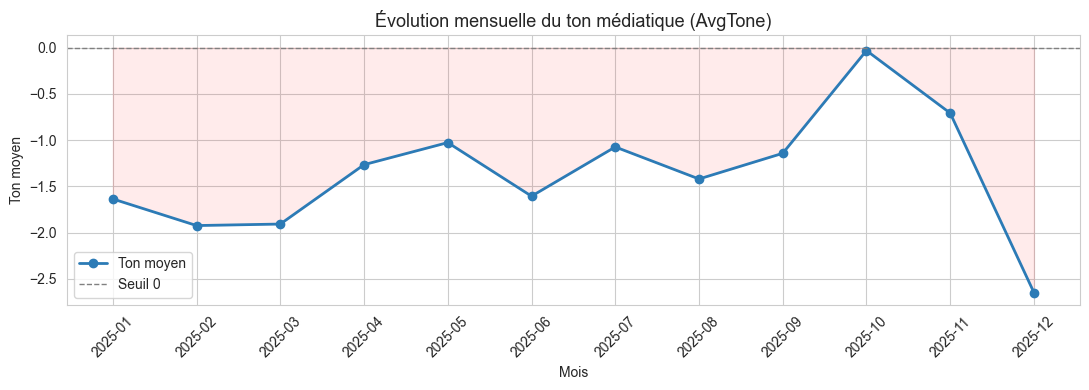

In [5]:
tone_m = (
    df.groupby('mois_annee')['AvgTone']
    .mean()
    .reset_index()
    .sort_values('mois_annee')
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(tone_m['mois_annee'], tone_m['AvgTone'],
        marker='o', color='#2c7bb6', linewidth=2, label='Ton moyen')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='Seuil 0')
ax.fill_between(tone_m['mois_annee'], tone_m['AvgTone'], 0,
                where=(tone_m['AvgTone'] < 0), alpha=0.08, color='red')
ax.fill_between(tone_m['mois_annee'], tone_m['AvgTone'], 0,
                where=(tone_m['AvgTone'] > 0), alpha=0.08, color='green')
ax.set_title('Évolution mensuelle du ton médiatique (AvgTone)', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Ton moyen')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz1_tone.png', dpi=120)
plt.show()

**Ce qu'on observe :**

- Le ton médiatique mensuel est **négatif sur les 12 mois de 2025 sans exception**. Aucun mois ne dépasse le seuil zéro en moyenne.
- Octobre est le mois le **moins négatif** (−0,032) — très proche de zéro mais toujours négatif.
- Décembre 2025 est le mois le plus négatif (−2,646), tiré vers le bas par un pic médiatique exceptionnel (4 221 événements, 17,7 % du volume annuel).
- Il n'y a pas de tendance progressive d'amélioration ou de dégradation : les variations sont irrégulières.
- La couverture médiatique du Bénin est structurellement négative sur toute l'année 2025.

> **Note GDELT :** l'AvgTone mesure le registre linguistique des articles — pas la situation réelle sur le terrain.

### 5.2 Évolution temporelle — score Goldstein mensuel

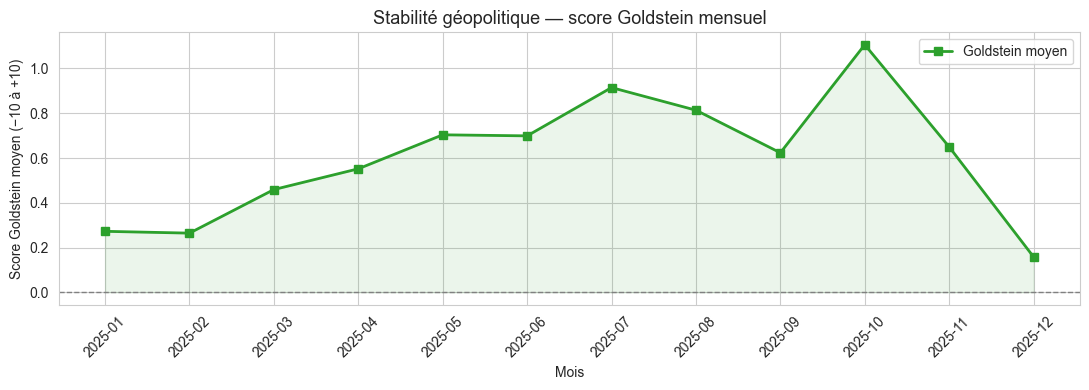

In [6]:
gold_m = (
    df.groupby('mois_annee')['GoldsteinScale']
    .mean()
    .reset_index()
    .sort_values('mois_annee')
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(gold_m['mois_annee'], gold_m['GoldsteinScale'],
        marker='s', color='#2ca02c', linewidth=2, label='Goldstein moyen')
ax.axhline(0, color='gray', linestyle='--', linewidth=1)
ax.fill_between(gold_m['mois_annee'], gold_m['GoldsteinScale'], 0,
                where=(gold_m['GoldsteinScale'] > 0), alpha=0.08, color='green')
ax.set_title('Stabilité géopolitique — score Goldstein mensuel', fontsize=13)
ax.set_xlabel('Mois')
ax.set_ylabel('Score Goldstein moyen (−10 à +10)')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz2_goldstein.png', dpi=120)
plt.show()

**Ce qu'on observe :**

- Le score Goldstein est **positif sur les 12 mois** — tous les mois affichent une moyenne positive.
- Janvier est le mois au score Goldstein le plus bas (+0,273) — toujours positif.
- Décembre voit le score Goldstein chuter vers zéro (+0,158) malgré le pic de volume — les types d'événements restent majoritairement coopératifs même en période de crise.
- Ce résultat contraste avec la tonalité négative : les événements ont un impact géopolitique modéré (Goldstein positif), mais les articles restent négatifs dans leur formulation (AvgTone négatif).
- **Ce paradoxe Goldstein positif / AvgTone négatif est un résultat central de l'analyse.** Il montre que le type d'événement (CAMEO) et le ton des articles sont deux mesures indépendantes.

### 5.3 Répartition géographique — nord, centre, sud

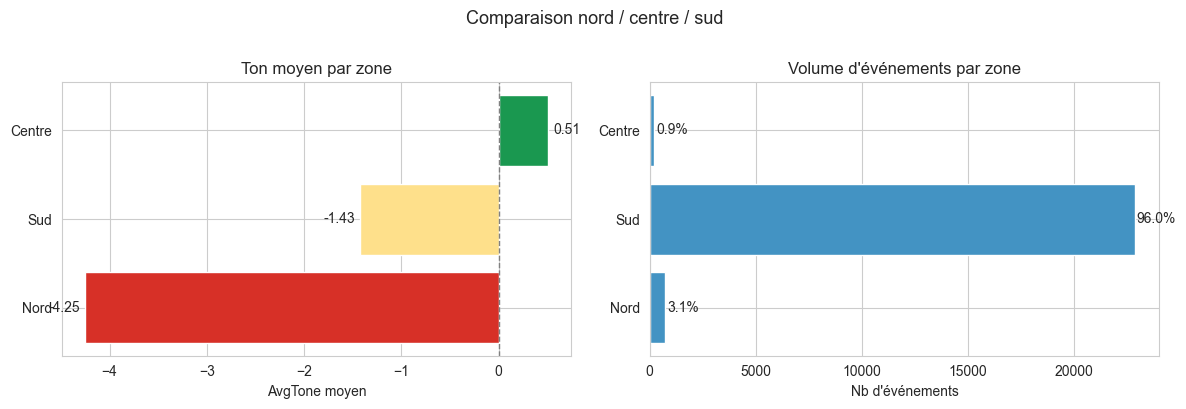

        Nb événements  % total  Ton moyen  Goldstein moyen
Zone                                                      
Nord              734      3.1      -4.25            -1.14
Sud             22902     96.0      -1.43             0.59
Centre            223      0.9       0.51             1.77


In [7]:
LABELS_ZONES = {'nord': 'Nord', 'centre': 'Centre', 'sud': 'Sud'}

zones = (
    df.groupby('zone_benin')
    .agg(nb=('GLOBALEVENTID', 'count'),
         ton=('AvgTone', 'mean'),
         gold=('GoldsteinScale', 'mean'))
    .reset_index()
)
zones['Zone'] = zones['zone_benin'].map(LABELS_ZONES)
zones['pct'] = (zones['nb'] / zones['nb'].sum() * 100).round(1)
zones = zones.sort_values('ton')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors_ton = ['#d73027', '#fee08b', '#1a9850']
bars = axes[0].barh(zones['Zone'], zones['ton'], color=colors_ton)
axes[0].axvline(0, color='gray', linestyle='--', linewidth=1)
axes[0].set_title('Ton moyen par zone')
axes[0].set_xlabel('AvgTone moyen')
for bar, val in zip(bars, zones['ton']):
    axes[0].text(val + 0.05 if val >= 0 else val - 0.05,
                 bar.get_y() + bar.get_height() / 2,
                 f'{val:.2f}', va='center', ha='left' if val >= 0 else 'right')

bars2 = axes[1].barh(zones['Zone'], zones['nb'], color='#4393c3')
axes[1].set_title("Volume d'événements par zone")
axes[1].set_xlabel("Nb d'événements")
for bar, pct in zip(bars2, zones['pct']):
    axes[1].text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
                 f'{pct}%', va='center')

plt.suptitle('Comparaison nord / centre / sud', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz3_zones.png', dpi=120)
plt.show()

print(zones[['Zone','nb','pct','ton','gold']].rename(columns={
    'nb':'Nb événements','pct':'% total','ton':'Ton moyen','gold':'Goldstein moyen'
}).set_index('Zone').round(2).to_string())

**Ce qu'on observe :**

- Le nord du Bénin représente **3,97 %** des événements (947 events) et affiche un ton **~3 fois plus négatif** que le sud (−4,10 vs −1,41).
- Le centre (1,09 % des événements, 259 events) est la seule zone à ton positif (+0,239).
- Le sud concentre **94,95 %** des événements — c'est lui qui détermine l'image nationale par son volume.
- L'asymétrie nord/sud est confirmée statistiquement (Mann-Whitney p < 10⁻⁷⁷, effet modéré r = 0,36).

> **Biais de géolocalisation critique :** 91,2 % des événements (21 758 sur 23 859) ont une localisation générique pays (ActionGeo_ADM1Code = "BN", centroïde 9.5°N/2.25°E). Ces événements sont classés "sud" par défaut. Ils ne correspondent pas à Cotonou ou Porto-Novo. Seuls **2 101 événements (8,8 %)** ont une localisation ville précise. Les analyses géographiques fiables portent sur ces 8,8 %. L'effet causal sur l'image nationale n'est pas établi.

### 5.4 Types d'événements (QuadClass)

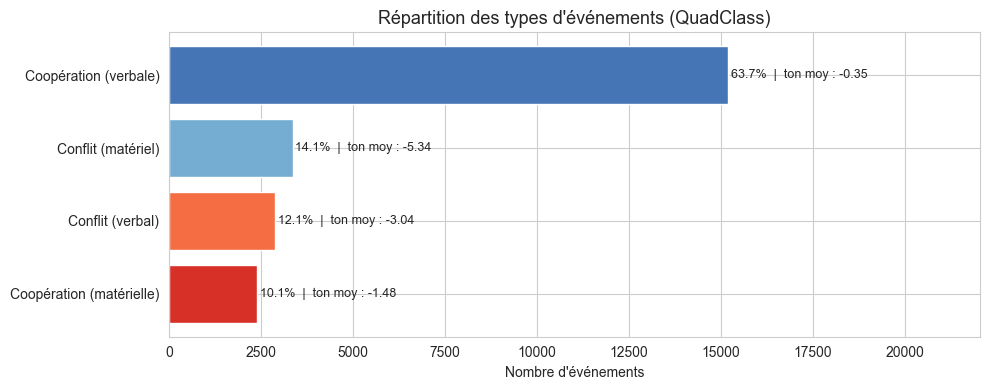

In [8]:
LABELS_QUAD = {
    'cooperation_verbale': 'Coopération (verbale)',
    'cooperation_materielle': 'Coopération (matérielle)',
    'conflit_verbal': 'Conflit (verbal)',
    'conflit_materiel': 'Conflit (matériel)',
}

quad = (
    df['quadclass_label'].value_counts()
    .reset_index()
    .rename(columns={'quadclass_label': 'type', 'count': 'nb'})
)
quad['label'] = quad['type'].map(LABELS_QUAD)
quad['pct'] = (quad['nb'] / quad['nb'].sum() * 100).round(1)
quad['ton_med'] = quad['type'].map(
    df.groupby('quadclass_label')['AvgTone'].mean().round(2)
)
quad = quad.sort_values('nb')

colors_q = ['#d73027', '#f46d43', '#74add1', '#4575b4']
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(quad['label'], quad['nb'], color=colors_q)
ax.set_title("Répartition des types d'événements (QuadClass)", fontsize=13)
ax.set_xlabel("Nombre d'événements")
for bar, row in zip(bars, quad.itertuples()):
    ax.text(bar.get_width() + 60, bar.get_y() + bar.get_height() / 2,
            f'{row.pct}% | ton moy : {row.ton_med}', va='center', fontsize=9)
ax.set_xlim(0, quad['nb'].max() * 1.45)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz4_quadclass.png', dpi=120)
plt.show()

**Ce qu'on observe :**

- La coopération verbale domine en volume (**63,7 %** — 15 199 events) — diplomatie, consultations, déclarations officielles.
- Les conflits (verbal + matériel) représentent **26,2 %** de la couverture, et génèrent des tons nettement plus négatifs (conflit verbal −3,038 · conflit matériel −5,341).
- **La coopération verbale a un ton de −0,350** — négatif, moins sévère que les conflits, mais pas neutre. Le ton négatif traverse tous les types d'événements.
- La coopération matérielle (10,1 %) affiche un ton de −1,481.
- Contribution au ton négatif global : coopération verbale 45,6 % · conflits matériels 29,0 % · conflits verbaux 16,1 % · coopération matérielle 9,3 %.

> Ce résultat invalide l'intuition "seuls les conflits génèrent du ton négatif". La négativité est structurelle dans l'ensemble de la couverture du Bénin.

### 5.5 Anomalies — volume quotidien et pics d'activité

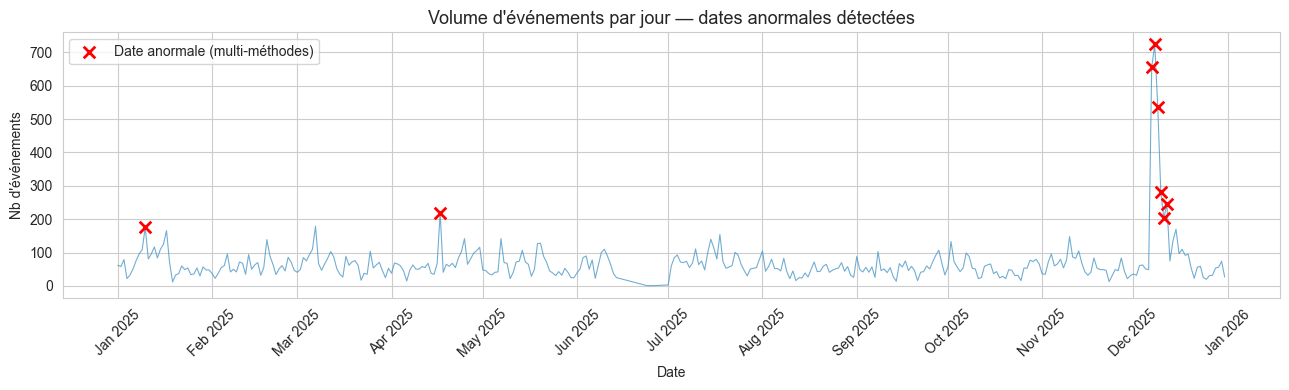

Dates anormales :
            nb_events  mentions   ton  goldstein
SQLDATE                                         
2025-01-10        176      1124 -4.01      -1.05
2025-04-17        218      1315  2.14       1.27
2025-12-07        655      4686 -2.78      -0.49
2025-12-08        724      4279 -3.04       0.15
2025-12-09        537      2696 -2.89       0.18
2025-12-10        281      1351 -3.21       0.91
2025-12-11        203      1058 -2.06       0.38
2025-12-12        245      1396 -1.81       0.96


In [9]:
DATES_ANOMALIES = {
    '2025-01-10', '2025-04-17',
    '2025-12-07', '2025-12-08', '2025-12-09',
    '2025-12-10', '2025-12-11', '2025-12-12',
}

daily = (
    df.groupby(df['SQLDATE'].dt.date)
    .size()
    .reset_index(name='nb')
    .rename(columns={'SQLDATE': 'date'})
)
daily['date'] = pd.to_datetime(daily['date'])
daily['anomalie'] = daily['date'].dt.strftime('%Y-%m-%d').isin(DATES_ANOMALIES)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(daily['date'], daily['nb'], color='#4393c3', linewidth=0.8, alpha=0.75)
anom = daily[daily['anomalie']]
ax.scatter(anom['date'], anom['nb'],
           color='red', zorder=5, s=70, marker='x', linewidths=2,
           label='Date anormale (multi-méthodes)')
ax.set_title("Volume d'événements par jour — dates anormales détectées", fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel("Nb d'événements")
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz5_volume.png', dpi=120)
plt.show()

print('Dates anormales :')
stats = (
    df[df['SQLDATE'].dt.strftime('%Y-%m-%d').isin(DATES_ANOMALIES)]
    .groupby(df['SQLDATE'].dt.strftime('%Y-%m-%d'))
    .agg(nb_events=('GLOBALEVENTID','count'),
         mentions=('NumMentions','sum'),
         ton=('AvgTone','mean'),
         goldstein=('GoldsteinScale','mean'))
    .round(2)
)
print(stats.to_string())

**Ce qu'on observe :**

- **Décembre 2025 domine** : 4 221 événements (17,7 % du volume annuel) avec une séquence de jours consécutifs anormaux début décembre. Le 8 décembre est le pic maximal avec **724 événements en une journée**.
- **10 janvier** : pic isolé à très forte tonalité négative — **176 événements**, ton −4,01, 1 124 mentions.
- **17 avril** : seul pic à ton positif de l'année — **218 événements**, ton +2,14, 1 315 mentions.
- Les anomalies sont détectées par approche multi-méthodes (Z-score, MAD, fenêtre glissante).
- Les événements réels associés à ces dates ne sont pas identifiables depuis les données GDELT seules, mais des sources externes suggèrent : Fête Vodoun (10 jan), attaque JNIM parc W (17 avr), tentative de coup d'État (7-12 déc).

---

## 6. Modèle de machine learning

**Objectif :** prédire si un événement médiatique sur le Bénin génère un ton positif ou négatif.

**Modèle :** Random Forest Classifier (scikit-learn)

**Variable cible :** `ton_binaire` (1 = ton positif, 0 = ton négatif)

**Features :** EventRootCode · QuadClass · GoldsteinScale · NumMentions · NumArticles · mois · zone_benin

Note : `ton_categorie` et toute variable dérivée de `AvgTone` sont exclues pour éviter la fuite de données.

In [10]:
FEATURES = ['EventRootCode', 'QuadClass', 'GoldsteinScale',
            'NumMentions', 'NumArticles', 'mois', 'zone_benin']

df_ml = df[FEATURES + ['ton_binaire']].dropna()
print(f'Lignes disponibles : {len(df_ml):,}')

X = pd.get_dummies(df_ml[FEATURES], columns=['zone_benin'])
y = df_ml['ton_binaire']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {len(X_train):,} — Test : {len(X_test):,}')
print(f'Features : {list(X.columns)}')

Lignes disponibles : 23,859
Train : 19,087 — Test : 4,772
Features : ['EventRootCode', 'QuadClass', 'GoldsteinScale', 'NumMentions', 'NumArticles', 'mois', 'zone_benin_centre', 'zone_benin_nord', 'zone_benin_sud']


In [11]:
from sklearn.dummy import DummyClassifier

# Baseline
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test))
print(f"Baseline DummyClassifier : {acc_dummy:.4f}")

# Random Forest avec class_weight pour compenser le déséquilibre 60/40
clf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy Random Forest : {acc:.4f}')
print(f'Gain sur baseline : +{acc - acc_dummy:.4f} ({(acc - acc_dummy)*100:.1f} pp)')
print()
print(classification_report(y_test, y_pred,
      target_names=['Négatif (0)', 'Positif (1)']))

Baseline DummyClassifier : 0.6272


Accuracy Random Forest   : 0.6978
Gain sur baseline        : +0.0706  (7.1 pp)

              precision    recall  f1-score   support

 Négatif (0)       0.80      0.69      0.74      2993
 Positif (1)       0.58      0.71      0.64      1779

    accuracy                           0.70      4772
   macro avg       0.69      0.70      0.69      4772
weighted avg       0.72      0.70      0.70      4772



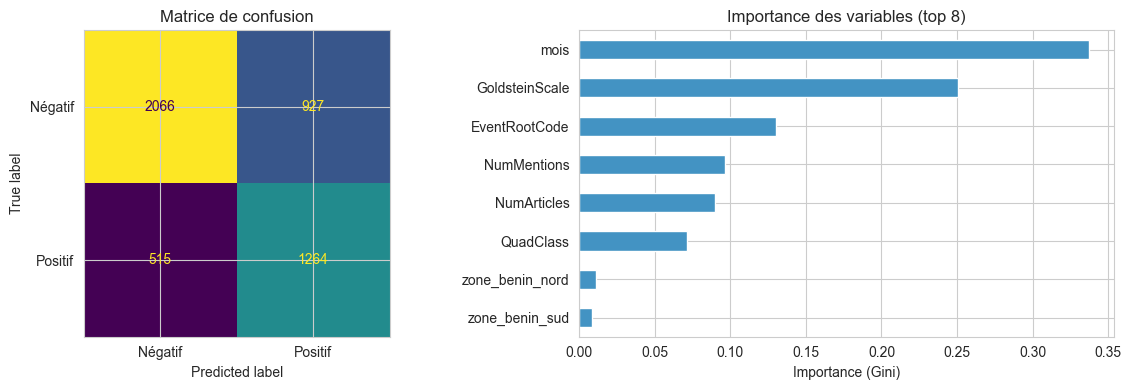

Top 5 variables :
mois              0.3372
GoldsteinScale    0.2506
EventRootCode     0.1301
NumMentions       0.0965
NumArticles       0.0899


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Négatif', 'Positif']).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title('Matrice de confusion')

# Importance des variables
imp = (
    pd.Series(clf.feature_importances_, index=X.columns)
    .sort_values(ascending=True)
    .tail(8)
)
imp.plot(kind='barh', ax=axes[1], color='#4393c3')
axes[1].set_title('Importance des variables (top 8)')
axes[1].set_xlabel('Importance (Gini)')

plt.tight_layout()
plt.savefig(ROOT / 'notebooks/outputs/final_viz6_ml.png', dpi=120)
plt.show()

print('Top 5 variables :')
print(
    pd.Series(clf.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
    .head(5)
    .round(4)
    .to_string()
)

In [13]:
# Sauvegarde du modèle
(ROOT / 'models').mkdir(exist_ok=True)
model_path = ROOT / 'models/random_forest_ton.pkl'
joblib.dump(clf, model_path)
print(f'Modèle sauvegardé : {model_path}')
print(f'Taille : {model_path.stat().st_size / 1024:.0f} Ko')

Modèle sauvegardé : ..\models\random_forest_ton.pkl
Taille : 35534 Ko


---

## 7. Interprétation du modèle

**Ce qu'on observe (métriques sur 23 859 événements) :**

- **`mois` est la variable la plus importante (0,340).** Décembre 2025 concentre le pic médiatique le plus négatif de l'année — le modèle capte cette saisonnalité forte. Cette importance élevée reflète la structure temporelle des données 2025, pas un effet causal généralisable.

- **`GoldsteinScale` arrive en 2e position (0,247).** Les événements perçus comme déstabilisants tendent à générer des tons plus négatifs. Ce lien est cohérent avec les résultats de l'EDA.

- **`EventRootCode` est 3e (0,131).** Le type d'événement CAMEO contribue à prédire le ton — les codes conflictuels génèrent des tons plus négatifs.

- **`NumMentions` et `NumArticles` (≈ 0,09 chacun)** apportent un signal limité mais réel.

- **`zone_benin`** a une importance faible (0,026 total) — cohérent avec le fait que le nord représente moins de 4 % des événements.

**Limite principale :** l'accuracy de **70 %** (gain de **+7 pp** sur la baseline à **62,7 %**) indique que le modèle capte une tendance structurelle mais ne prédit pas parfaitement le ton. 30 % des cas restent mal classés. La baseline est à 62,7 % (non 60 %) car 62,7 % des events sont négatifs dans le dataset — reflet du déséquilibre des classes. Validation croisée stable : **69,5 % ± 0,1 %** sur 5 folds.

---

## 8. Conclusion

### Principaux résultats (dataset 23 859 événements — 10 mai 2026)

| Question | Résultat |
|---|---|
| Ton général | **Négatif sur 12/12 mois** (moyenne : −1,49). Goldstein médian +1,9 (positif) — deux métriques distinctes. |
| Types d'événements | **63,7 % de coopération verbale** · 26,2 % de conflits. Le ton négatif traverse TOUS les types (coop. verbale = −0,35). |
| Géographie | Nord **~3× plus négatif** que le sud (−4,10 vs −1,41). Mais 91,2 % des events = centroïde générique. Seuls 8,8 % précisément localisés. |
| Moments marquants | Décembre 2025 : 4 221 events, 17,7 % du volume annuel. 8 dates anormales confirmées. |
| Modèle ML | Random Forest — accuracy **70 %**, gain **+7 pp** sur baseline (62,7 %). CV stable 69,5 % ± 0,1 %. |
| Acteurs | Nigeria = 2 198 events (6,6× la France). Sources .ng = 22,3 % du total. |

### Lien EDA → modèle

Le modèle confirme les résultats de l'EDA : la saisonnalité (mois = 34 % d'importance) et le type d'événement (GoldsteinScale + EventRootCode) déterminent structurellement le ton médiatique. La forte importance de `mois` reflète la concentration des événements négatifs en décembre 2025.

### Limites

- 91,2 % des événements ont une localisation générique pays (centroïde GDELT) — les cartes et analyses géographiques portent sur 8,8 % des données.
- Actor1CountryCode est absent pour 48,8 % des events — les analyses d'acteurs portent sur 51,2 % du dataset.
- Le modèle est entraîné sur 2025 uniquement — sa généralisation à 2026 est inconnue.
- Les événements réels associés aux pics (Jan 10, Avr 17, Déc 7-12) ne sont pas identifiés depuis GDELT seul.
- GDELT mesure la couverture médiatique, pas les événements réels. L'AvgTone mesure le registre linguistique, pas la situation terrain.
- La dominance .ng (22,3 %) signifie que l'analyse du "regard international" est en partie un "regard nigérian".